Setting up the environment and importing the necessary packages

In [1]:
import sys
!{sys.executable} -m pip install duckdb

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import duckdb

In [3]:
con = duckdb.connect(r'C:\Users\phikh\Desktop\Assessment - Durban\Game\casino_games_models\dev.duckdb')

Query strings for duckdb extracting data

In [4]:
tables = con.sql("SHOW TABLES").df()
display(tables)

,name
0,br_dim_currency
1,br_dim_game
2,br_fact_activity
3,gl_activity
4,gl_game
5,slv_dim_currency
6,slv_dim_game
7,slv_fact_activity


In [5]:
query_activity = "SELECT * FROM gl_activity"
query_game = "SELECT * FROM gl_game"

In [9]:
df_activity = con.execute(query_activity).fetchdf()
df_games = con.execute(query_game).fetchdf()

In [11]:
df_activity.head()


,activity_date,casino_id,player_id,game_id,total_spins,goline_date,total_wager_rated,total_payout,net_wins
0,2026-06-22,CASINO_447,PLAYER_1430360,GAME_6666,97.0,2026-06-04,51093.173411,38587.822502,12505.350909
1,2026-06-22,CASINO_390,PLAYER_1430364,GAME_5036,10.0,2026-05-30,2544.492073,404.220376,2140.271697
2,2026-06-23,CASINO_390,PLAYER_1430364,GAME_5992,4.0,2026-03-22,365.940205,0.000000,365.940205
3,2026-06-23,CASINO_390,PLAYER_1430364,GAME_4161,39.0,2025-12-20,18758.309093,7104.161712,11654.147380
4,2026-06-22,CASINO_240,PLAYER_1430402,GAME_6012,11.0,2026-06-30,2722.677154,0.000000,2722.677154


In [12]:
df_games.head()

,game_id,game_type,themes,mechanics
0,GAME_11344,TYPE_1,"[THEME_24, THEME_70, THEME_96]",[]
1,GAME_11373,TYPE_2,"[THEME_24, THEME_70, THEME_96]",[]
2,GAME_11317,TYPE_3,"[THEME_24, THEME_28, THEME_70]",[]
3,GAME_11318,TYPE_3,"[THEME_24, THEME_28, THEME_70]",[]
4,GAME_11364,TYPE_4,"[THEME_24, THEME_70, THEME_96]",[]


In [13]:
df_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973831 entries, 0 to 973830
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   activity_date      973831 non-null  datetime64[us]
 1   casino_id          973831 non-null  object        
 2   player_id          973831 non-null  object        
 3   game_id            973831 non-null  object        
 4   total_spins        973831 non-null  float64       
 5   goline_date        973831 non-null  datetime64[us]
 6   total_wager_rated  973831 non-null  float64       
 7   total_payout       973831 non-null  float64       
 8   net_wins           973831 non-null  float64       
dtypes: datetime64[us](2), float64(4), object(3)
memory usage: 66.9+ MB


In [14]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12413 entries, 0 to 12412
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   game_id    12413 non-null  object
 1   game_type  12413 non-null  object
 2   themes     12413 non-null  object
 3   mechanics  12413 non-null  object
dtypes: object(4)
memory usage: 388.0+ KB


Checking For Missing values.

In [17]:
print('Checking for missing values, even though we can clearly see from info of both the dataframs that there are no missing values')

Checking for missing values, even though we can clearly see from info of both the dataframs that there are no missing values


In [18]:
df_activity.isnull().sum()

activity_date        0
casino_id            0
player_id            0
game_id              0
total_spins          0
goline_date          0
total_wager_rated    0
total_payout         0
net_wins             0
dtype: int64

Checking for anomaly detection

In [19]:
anomalies = {
    "Negative Wager": (df_activity['total_wager_rated'] < 0).sum(),
    "Negative Payout": (df_activity['total_payout'] < 0).sum(),
    "Negative Spins": (df_activity['total_spins'] < 0).sum()
}
print("\nAnomaly checks:")
for k, v in anomalies.items():
    print(f"{k}: {v}")


Anomaly checks:
Negative Wager: 0
Negative Payout: 0
Negative Spins: 0


Checking Correlation with the dataset


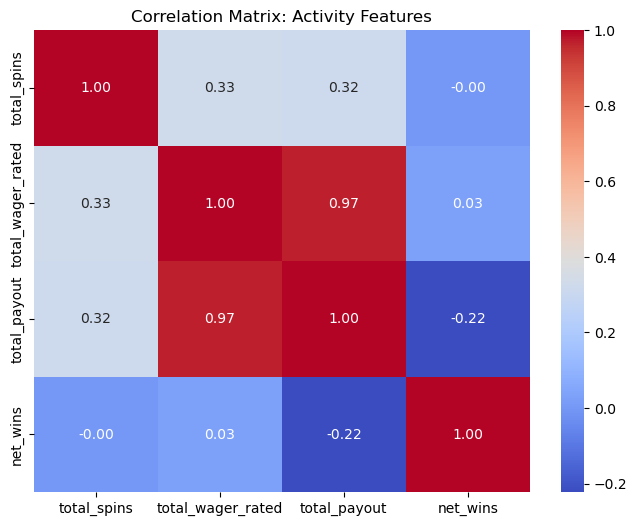

In [16]:
numeric_cols = df_activity.select_dtypes(include=[np.number])

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Activity Features")
plt.show()